# Die Pandas Bibliothek

## Vorbereitung

In [6]:
import pandas as pd
import numpy as np

%matplotlib inline

## Laden des Datensatzes

In [7]:
df = pd.read_csv('diamonds.csv')

* Datenexploration

In [8]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


## Zusammenfassung der Exploration

* Sauberer Datensatz
    * Keine fehlenden Daten
    * Datentypen sind fachlich korrekt erkannt worden
    * Unnamed: 0 ist überflüssig

## Cleanup

* Droppen der überflüssigen Spalte

In [10]:
unnecessary_column_name = 'Unnamed: 0'
if unnecessary_column_name in df.columns:
    df.drop(columns=[unnecessary_column_name], inplace=True)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Analyse

### Deskriptive Statistik

* Vereinfachte Annahme: die numerischen Spalten entsprechen einer Normalverteilung 
    * In den meisten Fällen ist dies nicht zu **100%** der Fall

In [11]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [12]:
df['price'].describe()

count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64

In [24]:
column = 'carat'
mean = df[column].mean()
median = df[column].median()
# mode = df[column].mode()
print(f'Mean={mean:.2f}, median={median:.2f}')

Mean=0.80, median=0.70


* Diagramme

array([[<Axes: title={'center': 'carat'}>,
        <Axes: title={'center': 'depth'}>,
        <Axes: title={'center': 'table'}>],
       [<Axes: title={'center': 'price'}>, <Axes: title={'center': 'x'}>,
        <Axes: title={'center': 'y'}>],
       [<Axes: title={'center': 'z'}>, <Axes: >, <Axes: >]], dtype=object)

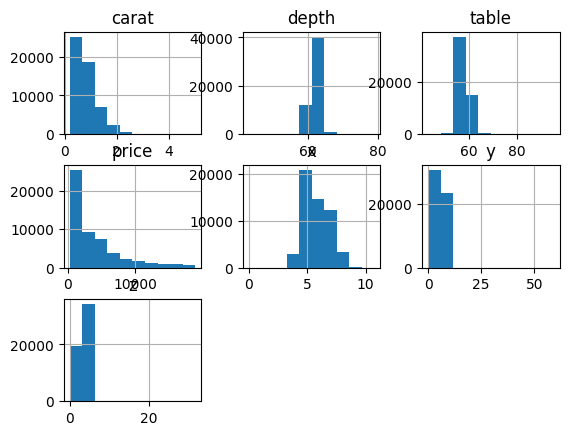

In [25]:
df.hist()

<Axes: >

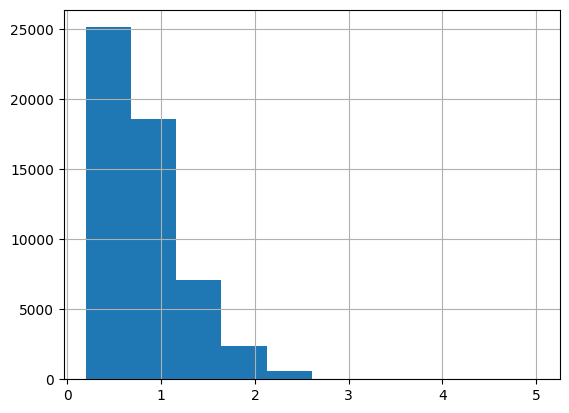

In [26]:
df['carat'].hist()

<Axes: >

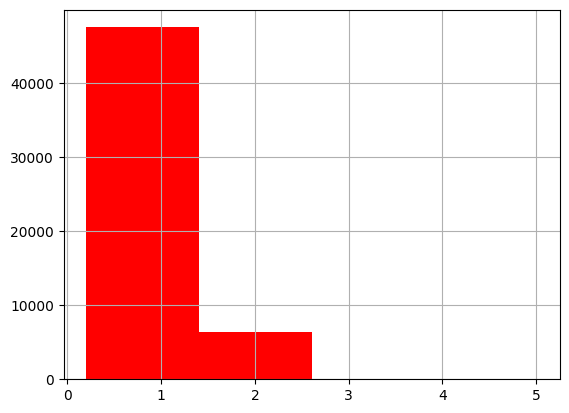

In [33]:
df['carat'].hist(color='red', bins=4)

* Boxplot

<Axes: >

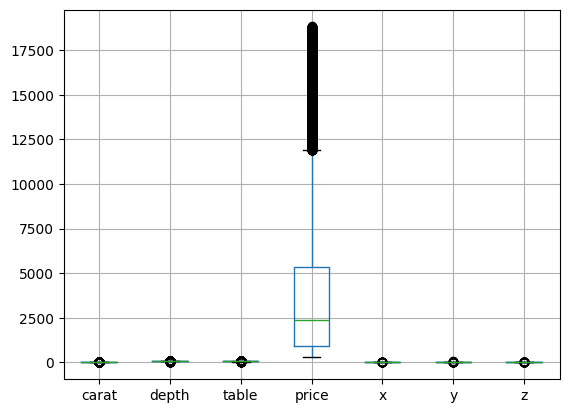

In [34]:
df.boxplot()

<Axes: >

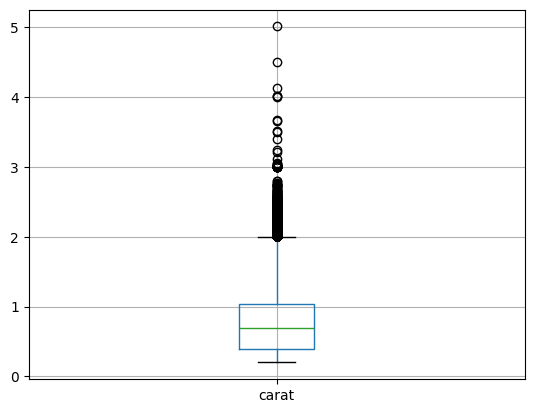

In [36]:
df.boxplot(column='carat')

<Axes: >

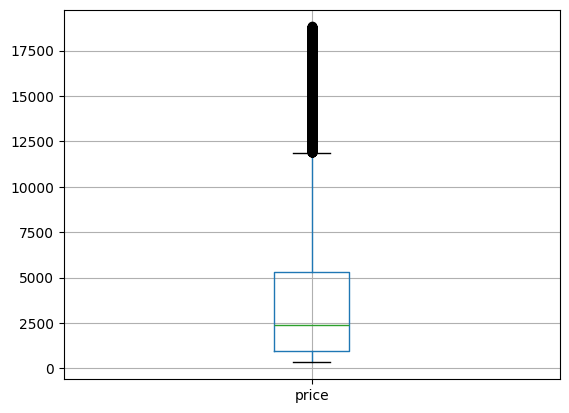

In [37]:
df.boxplot(column='price')

## Berechnungen mit Pandas

* Berechnungen erfolgen auf Basis von "Vektoren" bzw. Pandas-Series
    * Konkret: Es ist in den meisten Fällen nicht notwendig, eine Iteration kzu programmieren

* Beispiel: Näherungsweise Volumenberechnung

In [39]:
# volume_series = df['x']*df['y']*df['z']
# df['volume'] = volume_series
df['volume'] = df['x']*df['y']*df['z']
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250


* Filterung von Daten nach Kriterien

In [43]:
df['carat'] > 3.5

0        False
1        False
2        False
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Name: carat, Length: 53940, dtype: bool

In [ ]:
# criterion_series = df['carat'] > 3.5
#df[criterion_series]
df[df['carat'] > 3.5]


,carat,cut,color,clarity,depth,table,price,x,y,z,volume
23644,3.65,Fair,H,I1,67.1,53.0,11668,9.53,9.48,6.38,576.397272
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17,631.894380
25999,4.01,Premium,J,I1,62.5,62.0,15223,10.02,9.94,6.24,621.496512
26444,4.00,Very Good,I,I1,63.3,58.0,15984,10.01,9.94,6.31,627.841214
26534,3.67,Premium,I,I1,62.4,56.0,16193,9.86,9.81,6.13,592.934058
27130,4.13,Fair,H,I1,64.8,61.0,17329,10.00,9.85,6.43,633.355000
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98,790.133208
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72,698.455296
27679,3.51,Premium,J,VS2,62.5,59.0,18701,9.66,9.63,6.03,560.945574


<Axes: >

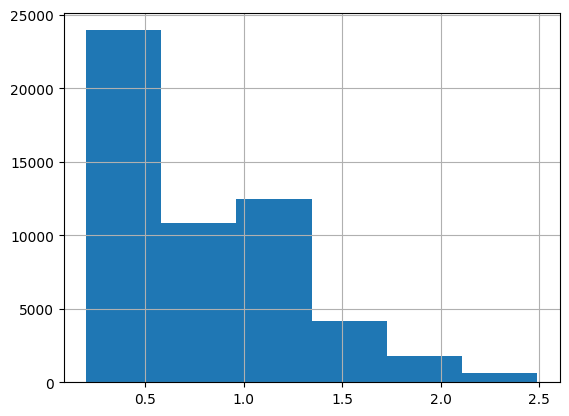

In [ ]:
df[df['carat'] < 3.5]['carat'].hist(bins=6)